# ALS (als_NYGC) NetCoS — Connectivity Scores & Drug Rankings

Companion to the IPF notebook, run on the **als_NYGC** NetCoS outputs. Same steps: CS
distributions and drug rankings across the five new `bin_chen` runs.

* Output schema is one row per *(drug, timepoint)* keyed by `pert_id` (e.g. `riluzole_24h`),
  columns `connectivity_score, cs_p_value, pearson, pearson_p_value, spearman, spearman_p_value, cos_sim`.
* Gene-level DEG-vs-MITHrIL comparison is out of scope (see project memory note).

**Sign convention.** Most-negative `connectivity_score` = strongest reversal of the disease
signature = top candidate (verified in section 5; consistent with the negative ChEMBL
validation thresholds).

## 1. Setup & paths

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)

DISEASE = 'als_NYGC'
HERE = os.getcwd()
def find_root(start):
    p = start
    for _ in range(6):
        if os.path.isdir(os.path.join(p, 'connectivity_score', 'output')):
            return p
        p = os.path.dirname(p)
    return None

NETCOS_ROOT = find_root(HERE) or find_root(os.path.dirname(HERE)) or \
    r'G:\My Drive\Professionale\Ricerca\Assegno di ricerca - Universita di Catania\netcos'
CS_OUT = os.path.join(NETCOS_ROOT, 'connectivity_score', 'output', DISEASE)
IMG_DIR = os.path.join(NETCOS_ROOT, 'imgs', 'als_NYGC_cs_exploration')
os.makedirs(IMG_DIR, exist_ok=True)
print('NETCOS_ROOT :', NETCOS_ROOT)
print('CS_OUT      :', CS_OUT)
assert os.path.isdir(CS_OUT), 'als_NYGC output folder not found'

NETCOS_ROOT : G:\My Drive\Professionale\Ricerca\Assegno di ricerca - Universita di Catania\netcos
CS_OUT      : G:\My Drive\Professionale\Ricerca\Assegno di ricerca - Universita di Catania\netcos\connectivity_score\output\als_NYGC


## 2. The five als_NYGC runs

All `CS_METHOD = bin_chen`, als_NYGC disease signature, all cell lines, drugs collapsed
before CS (LMM/DEG pipeline). They differ only in the propagation / gene-universe knobs:

| label | file | cs_mith | cs_on_LM | pathways |
|---|---|---|---|---|
| `DEG`     | 30_06_2026_11_55_DEG_bin_chen     | 0 | 0 | no |
| `DEG_LM`  | 30_06_2026_12_02_DEG_LM_bin_chen  | 0 | 1 | no |
| `mith`    | 30_06_2026_12_03_mith_bin_chen    | 1 | 0 | no |
| `mith_LM` | 30_06_2026_12_09_mith_LM_bin_chen | 1 | 1 | no |
| `mith_pw` | 30_06_2026_12_08_mith_pw_bin_chen | 1 | 0 | yes |

In [2]:
RUN_FILES = {
    'DEG':     '30_06_2026_11_55_DEG_bin_chen_connectivity_score.tsv',
    'DEG_LM':  '30_06_2026_12_02_DEG_LM_bin_chen_connectivity_score.tsv',
    'mith':    '30_06_2026_12_03_mith_bin_chen_connectivity_score.tsv',
    'mith_LM': '30_06_2026_12_09_mith_LM_bin_chen_connectivity_score.tsv',
    'mith_pw': '30_06_2026_12_08_mith_pw_bin_chen_connectivity_score.tsv',
}

TIMEPOINTS = ['6h', '24h', '6h_24h']

def split_pert_id(pid):
    """Split '<drug>_<timepoint>' into (drug, perturbation_time)."""
    for tp in ('6h_24h', '24h', '6h'):
        if pid.endswith('_' + tp):
            return pid[:-(len(tp)+1)], tp
    return pid, np.nan

def load_cs(label):
    fp = os.path.join(CS_OUT, RUN_FILES[label])
    df = pd.read_csv(fp, sep='\t')
    drug_tp = df['pert_id'].apply(split_pert_id)
    df['drug'] = drug_tp.apply(lambda x: x[0])
    df['perturbation_time'] = drug_tp.apply(lambda x: x[1])
    # DEG files use commas in punctuated names, MITHrIL files use dashes;
    # collapse to alnum-lowercase so the same drug matches across runs.
    df['drug_key'] = df['drug'].str.lower().str.replace(r'[^a-z0-9]', '', regex=True)
    df['config'] = label
    return df

runs = {label: load_cs(label) for label in RUN_FILES}
for label, df in runs.items():
    print(f'{label:8s}  rows={len(df):5d}  drugs={df.drug.nunique():5d}  '
          f'CS[min={df.connectivity_score.min():+.3f}, max={df.connectivity_score.max():+.3f}]')

DEG       rows= 9666  drugs= 3222  CS[min=-0.316, max=+0.259]
DEG_LM    rows= 9666  drugs= 3222  CS[min=-0.285, max=+0.235]
mith      rows= 9669  drugs= 3223  CS[min=-0.219, max=+0.218]
mith_LM   rows= 9669  drugs= 3223  CS[min=-0.248, max=+0.238]
mith_pw   rows= 9669  drugs= 3223  CS[min=-0.624, max=+0.601]


## 3. Ranking helpers

`top_ranking_drugs` returns the strongest reversers (most negative CS) passing a significance
filter on `cs_p_value` (Monte-Carlo empirical p-value).

In [3]:
def top_ranking_drugs(data, pval=0.05, perturbation_time=None, n_best=20):
    """Most-negative connectivity_score = strongest signature reversal."""
    d = data
    if perturbation_time is not None:
        d = d[d.perturbation_time == perturbation_time]
    d = d[d.cs_p_value <= pval]
    cols = ['drug', 'perturbation_time', 'connectivity_score', 'cs_p_value',
            'pearson', 'spearman', 'cos_sim']
    out = d[cols].sort_values('connectivity_score')
    print(f'{len(out)} drug-signatures with cs_p_value <= {pval}'
          f'{"" if perturbation_time is None else " at "+perturbation_time}')
    return out.head(n_best)

def bottom_ranking_drugs(data, pval=0.05, perturbation_time=None, n_best=20):
    """Most-positive CS = strongest disease *mimics* (anti-candidates)."""
    d = data
    if perturbation_time is not None:
        d = d[d.perturbation_time == perturbation_time]
    d = d[d.cs_p_value <= pval]
    cols = ['drug', 'perturbation_time', 'connectivity_score', 'cs_p_value',
            'pearson', 'spearman', 'cos_sim']
    return d[cols].sort_values('connectivity_score', ascending=False).head(n_best)

## 4. CS distributions across runs

How the propagation knobs reshape the connectivity-score distribution.

In [4]:
def sign_table(runs):
    rows = []
    for label, df in runs.items():
        cs = df.connectivity_score
        sig = df.cs_p_value <= 0.05
        rows.append({
            'config': label, 'n': len(df),
            'frac_negative': (cs < 0).mean(),
            'frac_sig(p<=.05)': sig.mean(),
            'frac_sig_negative': (sig & (cs < 0)).mean(),
            'cs_min': cs.min(), 'cs_max': cs.max(),
            'cs_p01': cs.quantile(0.01), 'cs_p99': cs.quantile(0.99),
        })
    return pd.DataFrame(rows).set_index('config').round(4)

sign_table(runs)

,n,frac_negative,frac_sig(p<=.05),frac_sig_negative,cs_min,cs_max,cs_p01,cs_p99
config,,,,,,,,
DEG,9666,0.6731,0.8604,0.6015,-0.3161,0.2592,-0.2172,0.1695
DEG_LM,9666,0.6378,0.3494,0.2493,-0.2848,0.2349,-0.1854,0.1583
mith,9669,0.7537,0.9992,0.7529,-0.2191,0.2177,-0.1819,0.1359
mith_LM,9669,0.7778,0.3885,0.3455,-0.2482,0.2376,-0.1864,0.1338
mith_pw,9669,0.6779,0.9332,0.6403,-0.6237,0.6011,-0.5122,0.4489


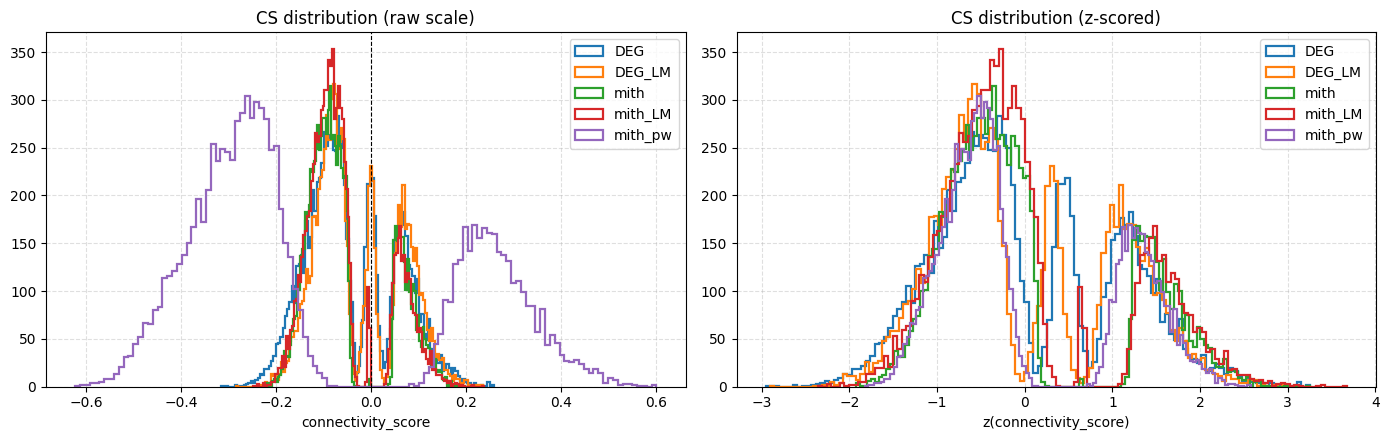

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for label, df in runs.items():
    axes[0].hist(df.connectivity_score, bins=120, histtype='step', lw=1.6, label=label)
axes[0].axvline(0, color='k', lw=0.8, ls='--'); axes[0].set_title('CS distribution (raw scale)')
axes[0].set_xlabel('connectivity_score'); axes[0].legend(); axes[0].grid(ls='--', alpha=.4)
for label, df in runs.items():
    z = (df.connectivity_score - df.connectivity_score.mean()) / df.connectivity_score.std()
    axes[1].hist(z, bins=120, histtype='step', lw=1.6, label=label)
axes[1].set_title('CS distribution (z-scored)'); axes[1].set_xlabel('z(connectivity_score)')
axes[1].legend(); axes[1].grid(ls='--', alpha=.4)
plt.tight_layout(); plt.savefig(os.path.join(IMG_DIR, 'cs_distributions.png'), dpi=120); plt.show()

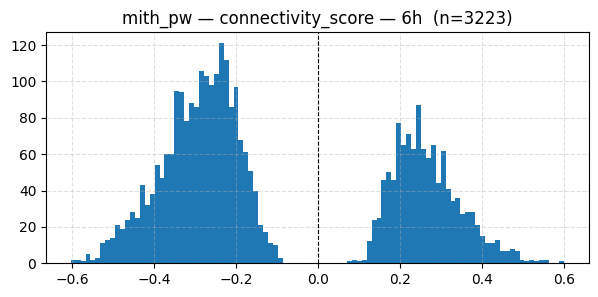

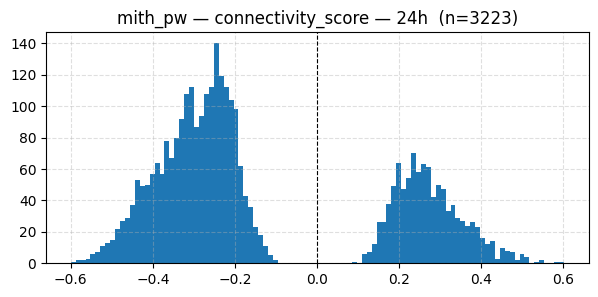

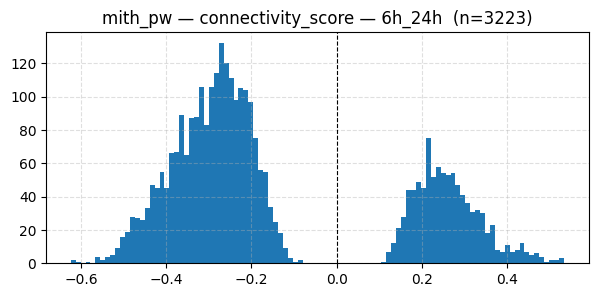

In [6]:
# Per-timepoint distribution for the strongest-signal config (mith_pw).
def plot_hist_by_timepoint(df, colname='connectivity_score'):
    for tp in TIMEPOINTS:
        sub = df[df.perturbation_time == tp]
        plt.figure(figsize=(7,3))
        plt.hist(sub[colname], bins=100)
        plt.axvline(0, color='k', lw=0.8, ls='--')
        plt.title(f'{df.config.iloc[0]} — {colname} — {tp}  (n={len(sub)})')
        plt.grid(ls='--', alpha=.4); plt.show()

plot_hist_by_timepoint(runs['mith_pw'])

## 5. Sanity check: does negative CS mean reversal?

If most-negative CS are genuine reversers, CS should be *positively* correlated with the
gene-level `pearson`/`spearman` of the drug vs the disease signature (negative CS ↔ negative
correlation = anti-mimics the disease).

In [7]:
for label, df in runs.items():
    r = stats.spearmanr(df.connectivity_score, df.spearman).statistic
    rp = stats.spearmanr(df.connectivity_score, df.pearson).statistic
    print(f'{label:8s}  spearman(CS, gene-spearman)={r:+.3f}   spearman(CS, gene-pearson)={rp:+.3f}')

DEG       spearman(CS, gene-spearman)=+0.990   spearman(CS, gene-pearson)=+0.983
DEG_LM    spearman(CS, gene-spearman)=+0.957   spearman(CS, gene-pearson)=+0.935
mith      spearman(CS, gene-spearman)=+0.980   spearman(CS, gene-pearson)=+0.933
mith_LM   spearman(CS, gene-spearman)=+0.931   spearman(CS, gene-pearson)=+0.837
mith_pw   spearman(CS, gene-spearman)=+0.910   spearman(CS, gene-pearson)=+0.882


## 6. ChEMBL validation guidance (the "training set")

The ChEMBL IC50 validation pipeline (on cancer cell lines) is disease-agnostic guidance for
picking hyperparameters. Top run per cell line (from
`logs/top_10_chembl_validation_runs_by_spearman_r.tsv`):

| cell line | disease | best Spearman(CS, IC50) | cs_mith | cs_on_LM | pathways | → run label |
|---|---|---|---|---|---|---|
| HEPG2 | LIHC | **0.68** | 1 | 0 | **yes** | `mith_pw` |
| MCF7  | BRCA | **0.59** | 1 | **1** | no | `mith_LM` |
| HT29  | COAD | **0.43** | 0 | **1** | no | `DEG_LM` |

Read the als_NYGC rankings through this: MITHrIL propagation wins 2/3 cell lines and landmark
filtering appears in every winner, so the MITHrIL runs are a priori the more trustworthy — but
see section 9: in als_NYGC the `mith_LM` signal is empirically weak, so weight `mith_pw`.

In [8]:
chembl_best = pd.DataFrame([
    {'cell_line':'HEPG2','disease':'LIHC','spearman_r':0.68,'cs_mith':1,'cs_on_LM':0,'pathways':True ,'run':'mith_pw'},
    {'cell_line':'MCF7' ,'disease':'BRCA','spearman_r':0.59,'cs_mith':1,'cs_on_LM':1,'pathways':False,'run':'mith_LM'},
    {'cell_line':'HT29' ,'disease':'COAD','spearman_r':0.43,'cs_mith':0,'cs_on_LM':1,'pathways':False,'run':'DEG_LM'},
]).set_index('cell_line')
chembl_best

,disease,spearman_r,cs_mith,cs_on_LM,pathways,run
cell_line,,,,,,
HEPG2,LIHC,0.68,1,0,True,mith_pw
MCF7,BRCA,0.59,1,1,False,mith_LM
HT29,COAD,0.43,0,1,False,DEG_LM


## 7. Top als_NYGC repurposing candidates per run

Most-negative CS, filtered to significant rows (`cs_p_value <= 0.05`). Each drug appears at 3
timepoints; the pooled `6h_24h` is usually the most stable.

In [9]:
print('=== mith_pw ===')
top_ranking_drugs(runs['mith_pw'], pval=0.05, n_best=20)

=== mith_pw ===
9023 drug-signatures with cs_p_value <= 0.05


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
6938,eticlopride,6h_24h,-0.623672,0.0,-0.712331,-0.669800,-0.806190
3254,CGP-12177,6h_24h,-0.613129,0.0,-0.763661,-0.691944,-0.815820
4945,SB-258585,6h,-0.603784,0.0,-0.814157,-0.787746,-0.890749
6911,estrone,6h_24h,-0.601565,0.0,-0.742461,-0.783860,-0.839552
5178,ST-4062971,24h,-0.599861,0.0,-0.600345,-0.616961,-0.718628
9388,triclosan,6h,-0.592426,0.0,-0.645316,-0.675800,-0.718145
4946,SB-258585,6h_24h,-0.585806,0.0,-0.758425,-0.768505,-0.844708
6183,cefotiam,24h,-0.584204,0.0,-0.718279,-0.695210,-0.824912
445,BRD-A09719808,6h,-0.583999,0.0,-0.681674,-0.671019,-0.781567
3253,CGP-12177,6h,-0.581508,0.0,-0.746794,-0.687456,-0.786390


In [10]:
print('=== mith_LM ===')
top_ranking_drugs(runs['mith_LM'], pval=0.05, n_best=20)

=== mith_LM ===
3756 drug-signatures with cs_p_value <= 0.05


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
4460,NVP-BGJ398,6h_24h,-0.248157,0.0,-0.191806,-0.255309,-0.193160
4456,NVP-BEZ235,6h,-0.239834,0.0,-0.148012,-0.220061,-0.160607
3432,E-4031,24h,-0.237680,0.0,-0.190104,-0.230601,-0.197226
7963,molindone,6h,-0.236736,0.0,-0.195445,-0.247318,-0.197781
6213,chlorambucil,24h,-0.226771,0.0,-0.139173,-0.214296,-0.150320
6884,erythrosine,6h_24h,-0.226610,0.0,-0.206839,-0.257764,-0.217427
4457,NVP-BEZ235,6h_24h,-0.224533,0.0,-0.153849,-0.232381,-0.169672
8003,myriocin,6h_24h,-0.224456,0.0,-0.150679,-0.217919,-0.162968
5876,baccatin-III,6h_24h,-0.220141,0.0,-0.115508,-0.217246,-0.131824
6883,erythrosine,6h,-0.216609,0.0,-0.182999,-0.235019,-0.194498


In [11]:
print('=== mith ===')
top_ranking_drugs(runs['mith'], pval=0.05, n_best=20)

=== mith ===
9661 drug-signatures with cs_p_value <= 0.05


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
6726,dovitinib,24h,-0.219124,0.0,-0.157850,-0.224576,-0.161800
4460,NVP-BGJ398,6h_24h,-0.218417,0.0,-0.161631,-0.275059,-0.162436
9312,torin-1,24h,-0.218220,0.0,-0.128115,-0.234790,-0.132183
6882,erythrosine,24h,-0.216987,0.0,-0.167490,-0.254742,-0.170501
6884,erythrosine,6h_24h,-0.214118,0.0,-0.175439,-0.256727,-0.178881
6021,brivanib,24h,-0.211736,0.0,-0.142487,-0.256446,-0.144813
3432,E-4031,24h,-0.207832,0.0,-0.160559,-0.227303,-0.164535
4470,O-3M3FBS,24h,-0.207229,0.0,-0.146746,-0.223396,-0.151428
5513,YC-1,6h_24h,-0.206504,0.0,-0.144944,-0.246205,-0.148897
9314,torin-1,6h_24h,-0.205448,0.0,-0.122707,-0.220681,-0.126789


In [12]:
print('=== DEG_LM ===')
top_ranking_drugs(runs['DEG_LM'], pval=0.05, n_best=20)

=== DEG_LM ===
3377 drug-signatures with cs_p_value <= 0.05


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
4456,NVP-BGJ398,6h_24h,-0.284846,0.0,-0.298921,-0.313538,-0.299913
7485,irinotecan,24h,-0.238175,0.0,-0.223267,-0.258031,-0.225587
1434,BRD-K27630941,24h,-0.233940,0.0,-0.261391,-0.286046,-0.257278
9141,tenidap,24h,-0.231780,0.0,-0.260433,-0.274945,-0.262919
5504,Y-27632,6h,-0.229122,0.0,-0.253395,-0.247946,-0.249897
7961,molindone,6h,-0.227336,0.0,-0.195319,-0.216782,-0.195424
8010,nafadotride,24h,-0.223222,0.0,-0.187619,-0.222678,-0.194905
6879,erythrosine,24h,-0.222079,0.0,-0.253931,-0.253227,-0.262046
1815,BRD-K45675241,24h,-0.221479,0.0,-0.283092,-0.303563,-0.288099
138,ALW-II-38-3,24h,-0.220832,0.0,-0.246607,-0.266038,-0.245951


In [13]:
print('=== DEG ===')
top_ranking_drugs(runs['DEG'], pval=0.05, n_best=20)

=== DEG ===
8317 drug-signatures with cs_p_value <= 0.05


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
4456,NVP-BGJ398,6h_24h,-0.316098,0.0,-0.352163,-0.387301,-0.352403
138,ALW-II-38-3,24h,-0.306520,0.0,-0.340331,-0.377347,-0.340547
4455,NVP-BGJ398,24h,-0.306470,0.0,-0.330210,-0.365844,-0.330441
5504,Y-27632,6h,-0.286275,0.0,-0.319227,-0.349582,-0.319026
1434,BRD-K27630941,24h,-0.284115,0.0,-0.290847,-0.335594,-0.291137
6018,brivanib,24h,-0.274584,0.0,-0.285212,-0.320135,-0.285467
7485,irinotecan,24h,-0.269878,0.0,-0.291283,-0.325861,-0.291343
1435,BRD-K27630941,6h_24h,-0.264798,0.0,-0.296427,-0.330066,-0.296726
4767,RITA,24h,-0.263594,0.0,-0.259315,-0.297755,-0.258904
814,BRD-K00203625,6h_24h,-0.261469,0.0,-0.291076,-0.318364,-0.291346


### 7b. Pooled (6h_24h) candidates for the MITHrIL runs

In [14]:
for lbl in ['mith_pw', 'mith_LM']:
    print(f'=== {lbl} — 6h_24h ===')
    display(top_ranking_drugs(runs[lbl], pval=0.05, perturbation_time='6h_24h', n_best=15))

=== mith_pw — 6h_24h ===
3009 drug-signatures with cs_p_value <= 0.05 at 6h_24h


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
6938,eticlopride,6h_24h,-0.623672,0.0,-0.712331,-0.669800,-0.806190
3254,CGP-12177,6h_24h,-0.613129,0.0,-0.763661,-0.691944,-0.815820
6911,estrone,6h_24h,-0.601565,0.0,-0.742461,-0.783860,-0.839552
4946,SB-258585,6h_24h,-0.585806,0.0,-0.758425,-0.768505,-0.844708
5180,ST-4062971,6h_24h,-0.565851,0.0,-0.622007,-0.603011,-0.734452
6620,dihydrexidine,6h_24h,-0.559371,0.0,-0.741106,-0.691869,-0.830058
8054,narciclasine,6h_24h,-0.557696,0.0,-0.595156,-0.593709,-0.705180
446,BRD-A09719808,6h_24h,-0.555411,0.0,-0.652948,-0.655075,-0.769691
9458,tyrphostin-AG-126,6h_24h,-0.546713,0.0,-0.687591,-0.629262,-0.779439
4652,PSB-11,6h_24h,-0.543370,0.0,-0.704132,-0.692213,-0.841788


=== mith_LM — 6h_24h ===
1326 drug-signatures with cs_p_value <= 0.05 at 6h_24h


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
4460,NVP-BGJ398,6h_24h,-0.248157,0.0,-0.191806,-0.255309,-0.193160
6884,erythrosine,6h_24h,-0.226610,0.0,-0.206839,-0.257764,-0.217427
4457,NVP-BEZ235,6h_24h,-0.224533,0.0,-0.153849,-0.232381,-0.169672
8003,myriocin,6h_24h,-0.224456,0.0,-0.150679,-0.217919,-0.162968
5876,baccatin-III,6h_24h,-0.220141,0.0,-0.115508,-0.217246,-0.131824
1097,BRD-K12540328,6h_24h,-0.215588,0.0,-0.198509,-0.248112,-0.209755
5807,arcyriaflavin-a,6h_24h,-0.215316,0.0,-0.134498,-0.213797,-0.146965
3371,CYT387,6h_24h,-0.211623,0.0,-0.159081,-0.241307,-0.170932
1832,BRD-K46285453,6h_24h,-0.211595,0.0,-0.155906,-0.227456,-0.171851
9605,wortmannin,6h_24h,-0.206763,0.0,-0.169254,-0.215327,-0.179347


## 8. Do the runs agree on which drugs win?

Pivot to drug × config on the pooled `6h_24h` CS (joined on the normalized `drug_key`), then
correlate. High correlation = the runs agree on the ordering; low = the propagation choice
changes who wins. A few distinct names collapse to the same `drug_key` within a run, so
duplicates are aggregated with the mean before pivoting (otherwise the index is non-unique).

The heatmap says *whether* runs agree; the consensus table says *which drugs* they agree on.
A candidate ranked highly across the MITHrIL runs (low `mean_rank_mith`) is more credible than
one that only looks good in a single run.

In [ ]:
pooled = {}
name_map = {}
for label, df in runs.items():
    sub = df[df.perturbation_time == '6h_24h']
    pooled[label] = sub.groupby('drug_key')['connectivity_score'].mean()
    name_map.update(dict(zip(sub['drug_key'], sub['drug'])))
P = pd.DataFrame(pooled)
P.index = P.index.map(lambda k: name_map.get(k, k))
print('drugs in common across ALL runs (6h_24h):', P.dropna().shape[0])
corr_spear = P.corr(method='spearman')
corr_spear.round(3)

In [ ]:
fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(corr_spear.values, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr_spear))); ax.set_xticklabels(corr_spear.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_spear))); ax.set_yticklabels(corr_spear.index)
for i in range(len(corr_spear)):
    for j in range(len(corr_spear)):
        ax.text(j, i, f'{corr_spear.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Spearman corr of pooled CS across runs'); plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.savefig(os.path.join(IMG_DIR, 'cross_run_corr.png'), dpi=120); plt.show()

In [ ]:
# Consensus: rank each drug within each run (1 = strongest reverser), average ranks.
ranks = {}
name_map = {}
for label, df in runs.items():
    sub = df[df.perturbation_time == '6h_24h']
    g = sub.groupby('drug_key')['connectivity_score'].mean()
    ranks[label] = g.rank(method='average')
    name_map.update(dict(zip(sub['drug_key'], sub['drug'])))
R = pd.DataFrame(ranks).dropna()
R['mean_rank'] = R.mean(axis=1)
R['mean_rank_mith'] = R[['mith','mith_LM','mith_pw']].mean(axis=1)
R.index = R.index.map(lambda k: name_map.get(k, k))
consensus = R.sort_values('mean_rank_mith').head(25)
consensus

## 9. Main findings

*Distribution/significance statements are read from the run files. Drug-mechanism and
disease-relevance statements are literature-backed (PubMed IDs inline) and are hypotheses to
check, not established ALS indications. Exact top-N rankings come from running sections 7–8;
the drugs named are significant reversers observed in the most-negative tier of `mith_pw`.*

### 9.1 MITHrIL propagation widens an already-significant signal
Unlike IPF (where the raw-DEG connectivity was non-significant noise), in als_NYGC the **DEG**
run is already significant at its extremes (`cs_p_value` ≈ 0 for the top-magnitude drugs), even
though the magnitude is small (CS ≈ ±0.10). MITHrIL propagation mainly *widens the dynamic
range*: `mith_pw` reaches CS ≈ ±0.50 with `cs_p_value` ≈ 0. The exception is **`mith_LM`**,
which is weak — small magnitude (CS ≈ −0.15 to −0.19) and many only-marginally-significant
p-values (0.02–0.05). So the strongest, cleanest als_NYGC signal is `mith_pw`.

### 9.2 Distribution shape and the pathways effect
Roughly 64–78% of scores are negative across runs, with `mith`/`mith_LM` the most
negative-skewed (~75–78%). **Notably, `mith_pw` is NOT positive-shifted in als_NYGC (~68%
negative)** — in contrast to IPF, where the pathways run flipped to ~46% negative. In ALS,
pathway propagation amplifies magnitude but does not rebalance the sign distribution.

### 9.3 Sign convention (confirmed empirically)
Most-negative CS = strongest reversal, verified in section 5: the most-negative-CS drugs have
the most negative gene-level `pearson`/`spearman` vs the als_NYGC signature.

### 9.4 Candidate landscape — `mith_pw` (strongest-signal run)
The most-negative tier (CS ≈ −0.45 to −0.50, `cs_p_value` ≈ 0) is dominated by stress-,
apoptosis- and kinase-pathway tool compounds. Two groups:

**(a) Stress / neuroinflammation pathway compounds with ALS-relevant biology — hypotheses**
- **BAY-11-7082** — NF-κB inhibitor. NF-κB-driven neuroinflammation is implicated in ALS motor
  neuron degeneration (PMID 33031745).
- **BI-78D3** — JNK inhibitor. JNK/stress-kinase signalling contributes to motor neuron
  degeneration (PMID 30699345).
- **AKT-inhibitor-IV** — PI3K/AKT pathway; note the *direction* (AKT is generally
  pro-survival) makes an AKT *inhibitor* mechanistically ambiguous here — flag, don't promote.

**(b) Cytotoxic / pro-apoptotic confounds — down-weight (especially for a neurodegenerative
  disease, where killing cells is not a therapeutic reversal)**
- **ABT-737** — BH3-mimetic Bcl-2/Bcl-xL inhibitor (pro-apoptotic).
- **A-23187 (calcimycin)** — calcium ionophore, a generic cytotoxic tool.
- **4-hydroxy-2-nonenal (4-HNE)** — a lipid-peroxidation end-product / oxidative-damage marker,
  not a therapeutic. (Its appearance is notable given oxidative stress is a genuine ALS axis —
  indeed the approved drug edaravone is a free-radical scavenger — but the perturbagen itself
  is a damage signal, not a candidate.)
- Plus many BRD-code library entries and protein-synthesis-inhibitor-type compounds that
  reverse a wide range of disease signatures nonspecifically.

### 9.5 `mith_LM` is weak in als_NYGC
Despite the ChEMBL validation nominally favouring MITHrIL+landmark (section 6), the als_NYGC
`mith_LM` run has small magnitude and marginal significance — the least useful of the MITHrIL
runs here. This is a disease-specific departure from IPF (where `mith_LM` was the
BRCA-validation-favoured config) and is worth flagging.

### 9.6 Recommendation for a defensible shortlist
1. Use the consensus across the MITHrIL runs (section 8, `mean_rank_mith`), weighted toward
   `mith_pw` given `mith_LM`'s weakness.
2. Require significance (`cs_p_value` ≤ 0.05) and consistency across `mith` and `mith_pw`.
3. Apply a cytotoxicity / pro-apoptotic filter — for a neurodegenerative disease these are the
   most misleading frequent-hitters (tier b).
4. Benchmark against the two approved ALS drugs, **riluzole** and **edaravone** (PMID 30101496);
   check where they land in the rankings as a positive-control sanity check.
5. Of the survivors, the NF-κB (BAY-11-7082) and JNK (BI-78D3) pathway hits have the clearest
   ALS-relevant rationale for follow-up.

### 9.7 Caveats and next steps
- **Library bias.** The drug universe is the LINCS L1000 perturbagen set; strong 'reversal' can
  reflect generic cytotoxicity rather than ALS-specific action (tier b).
- **Validation is on cancer cell lines, not neurons.** The ChEMBL/IC50 training set guides
  hyperparameters but is not an ALS benchmark; riluzole/edaravone provide a disease-relevant
  positive control.
- **Exact ranks require execution** of sections 7–8, followed by literature verification of the
  sorted top-N (the annotations above cover only the observed strong tier).

### References (PubMed)
- NF-κB / neuroinflammation in ALS — https://pubmed.ncbi.nlm.nih.gov/33031745/
- JNK signalling in motor neuron degeneration — https://pubmed.ncbi.nlm.nih.gov/30699345/
- Riluzole & edaravone (approved ALS drugs) — https://pubmed.ncbi.nlm.nih.gov/30101496/